#**CHAPTER 5. 합성곱 신경망 I - Part2**

#5.3 전이학습

##5.3.1 특성 추출 기법

In [ ]:
#특성 추출에 필요한 라이브러리 설치
!pip install opencv-python

  Using cached numpy-2.2.6-cp312-cp312-manylinux_2_17_x86_64.manylinux2014_x86_64.whl.metadata (62 kB)
Using cached numpy-2.2.6-cp312-cp312-manylinux_2_17_x86_64.manylinux2014_x86_64.whl (16.5 MB)
  Attempting uninstall: numpy
    Found existing installation: numpy 1.26.4
    Uninstalling numpy-1.26.4:
      Successfully uninstalled numpy-1.26.4
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
mxnet 1.9.1 requires numpy<2.0.0,>1.16.0, but you have numpy 2.2.6 which is incompatible.
tensorflow 2.19.0 requires numpy<2.2.0,>=1.26.0, but you have numpy 2.2.6 which is incompatible.
numba 0.60.0 requires numpy<2.1,>=1.22, but you have numpy 2.2.6 which is incompatible.


In [ ]:
#코드 5-12. 라이브러리 호출
import os
import time
import copy
import glob
import cv2  # 앞에서 설치한 OpenCV 라이브러리
import shutil

import torch
import torchvision  # 컴퓨터 비전 용도의 패키지
import torchvision.transforms as transforms  # 데이터 전처리를 위해 사용되는 패키지
import torchvision.models as models  # 다양한 파이토치 네트워크를 사용할 수 있도록 도와주는 패키지
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader

import matplotlib.pyplot as plt

In [ ]:
!pip install mxnet
!pip install --user mxnet

  Using cached numpy-1.26.4-cp312-cp312-manylinux_2_17_x86_64.manylinux2014_x86_64.whl.metadata (61 kB)
Using cached numpy-1.26.4-cp312-cp312-manylinux_2_17_x86_64.manylinux2014_x86_64.whl (18.0 MB)
  Attempting uninstall: numpy
    Found existing installation: numpy 2.2.6
    Uninstalling numpy-2.2.6:
      Successfully uninstalled numpy-2.2.6
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
thinc 8.3.6 requires numpy<3.0.0,>=2.0.0, but you have numpy 1.26.4 which is incompatible.
opencv-python 4.12.0.88 requires numpy<2.3.0,>=2; python_version >= "3.9", but you have numpy 1.26.4 which is incompatible.
opencv-contrib-python 4.12.0.88 requires numpy<2.3.0,>=2; python_version >= "3.9", but you have numpy 1.26.4 which is incompatible.
opencv-python-headless 4.12.0.88 requires numpy<2.3.0,>=2; python_version >= "3.9", but you have numpy 1.26.4 which is incompatible

ERROR: Operation cancelled by user
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/pip/_internal/cli/base_command.py", line 179, in exc_logging_wrapper
    status = run_func(*args)
             ^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/pip/_internal/cli/req_command.py", line 67, in wrapper
    return func(self, options, args)
           ^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/pip/_internal/commands/install.py", line 447, in run
    conflicts = self._determine_conflicts(to_install)
                ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/pip/_internal/commands/install.py", line 578, in _determine_conflicts
    return check_install_conflicts(to_install)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/pip/_internal/operations/check.py", line 101, in check_install_conflicts
    package_set, _ = create_package_

In [ ]:
!pip install --user mxnet

  Using cached numpy-1.26.4-cp312-cp312-manylinux_2_17_x86_64.manylinux2014_x86_64.whl.metadata (61 kB)
Using cached numpy-1.26.4-cp312-cp312-manylinux_2_17_x86_64.manylinux2014_x86_64.whl (18.0 MB)
  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
thinc 8.3.6 requires numpy<3.0.0,>=2.0.0, but you have numpy 1.26.4 which is incompatible.
opencv-python 4.12.0.88 requires numpy<2.3.0,>=2; python_version >= "3.9", but you have numpy 1.26.4 which is incompatible.
opencv-contrib-python 4.12.0.88 requires numpy<2.3.0,>=2; python_version >= "3.9", but you have numpy 1.26.4 which is incompatible.
opencv-python-headless 4.12.0.88 requires numpy<2.3.0,>=2; python_version >= "3.9", but you have numpy 1.26.4 which is incompatible.


In [ ]:
import numpy as np

# numpy>=1.24에서는 np.bool이 사라져서 직접 매핑
if not hasattr(np, "bool"):
    np.bool = bool

import mxnet as mx
from mxnet.gluon.data.vision import transforms


/tmp/ipython-input-869118080.py:4: FutureWarning: In the future `np.bool` will be defined as the corresponding NumPy scalar.
  if not hasattr(np, "bool"):


In [ ]:
#코드 5-13. 이미지 데이터 전처리 방법 정의
data_path='/content/drive/MyDrive/Euron9_DL/data/catanddog/train' #이미지 데이터가 위치한 경로 지정

transform = torchvision.transforms.Compose(
    [
        torchvision.transforms.Resize([256,256]),
        torchvision.transforms.RandomResizedCrop(224),
        torchvision.transforms.RandomHorizontalFlip(),
        torchvision.transforms.ToTensor()]
)
train_dataset = torchvision.datasets.ImageFolder(
    data_path,
    transform=transform
)
train_loader = torch.utils.data.DataLoader(
    train_dataset,
    batch_size=32,
    num_workers=8,
    shuffle=True
)
print(len(train_dataset))

385


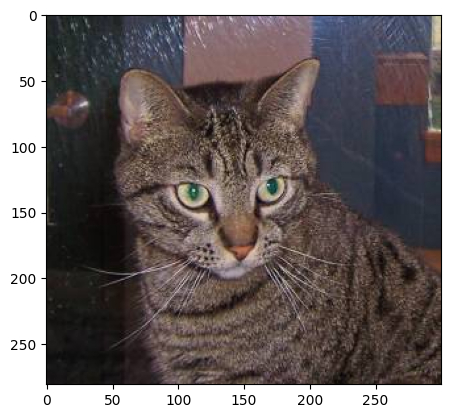

In [ ]:
#예시 코드를 통해 데이터 확장 코드 알아보기
import numpy as np
import matplotlib.pyplot as plt
import mxnet as mx
from mxnet.gluon.data.vision import transforms

example_image = mx.image.imread("/content/drive/MyDrive/Euron9_DL/data/catanddog/train/Cat/1.jpg") #예제를 진행할 이미지 불러오기
plt.imshow(example_image.asnumpy()) #불러온 이미지 출력

In [ ]:
#불러온 이미지에 RandomResizedCrop을 적용하기 위한 함수 생성
def show_images(imgs, num_rows, num_cols, scale=2):
  aspect_ratio = imgs[0].shape[0]/imgs[0].shape[1] #확장할 이미지의 크기 조정
  figsize = (num_cols * scale, num_rows*scale*aspect_ratio)
  _, axes = plt.subplots(num_rows, num_cols, figsize=figsize)
  for i in range(num_rows):
    for j in range(num_cols):
      axes[i][j].imshow(imgs[i*num_cols+j].asnumpy())
      axes[i][j].axes.get_xaxis().set_visible(False) #x축 전체를 숨김
      axes[i][j].axes.get_yaxis().set_visible(False) #y축 전체를 숨김
  plt.subplots_adjust(hspace=0.1, wspace=0)
  return axes

def apply(img, aug, num_rows=2, num_cols=4, scale=3):
  Y=[aug(img) for _ in range(num_rows*num_cols)] #다양한 샘플을 얻기 위해 여러 번 데이터 확장 적용
  show_images(Y, num_rows, num_cols, scale)

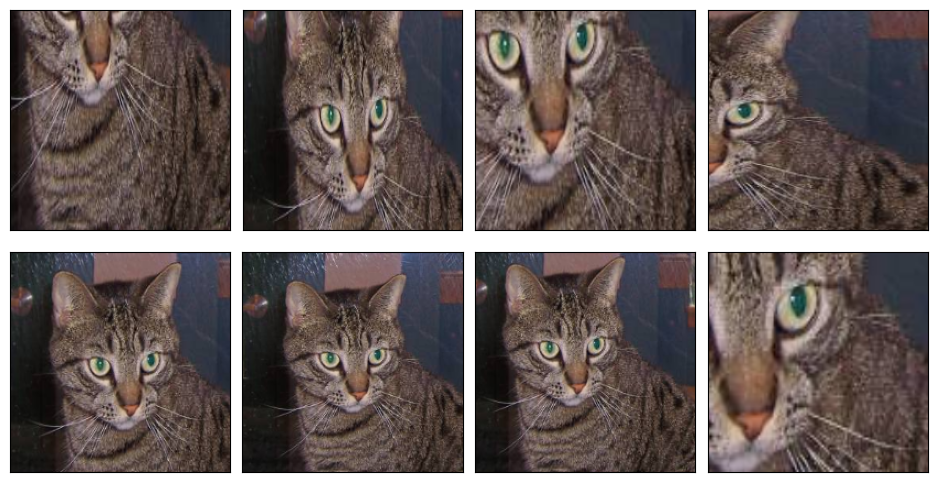

In [ ]:
shape_aug = transforms.RandomResizedCrop(size=(200,200),
                                         scale=(0.1, 1),
                                         ratio=(0.5, 2))
apply(example_image, shape_aug)

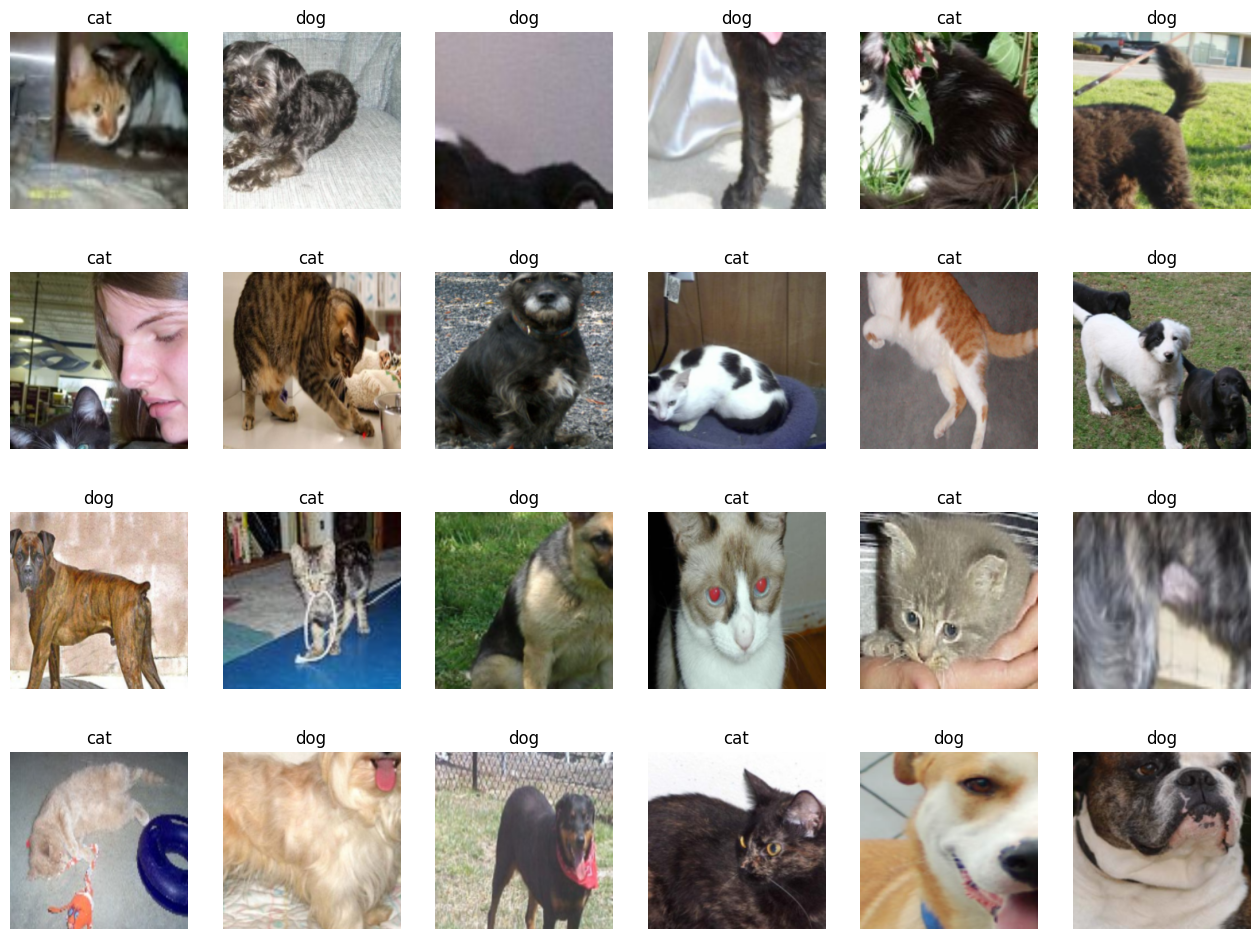

In [ ]:
#코드 5-14. 학습에 사용될 이미지 출력
samples, labels = next(iter(train_loader))
classes = {0: 'cat', 1:'dog'} #개와 고양이에 대한 클래스로 구성
fig = plt.figure(figsize=(16,24))
for i in range(24): #24개의 이미지 데이터 출력
  a = fig.add_subplot(4,6,i+1)
  a.set_title(classes[labels[i].item()]) #레이블 정보(클래스)를 함께 출력
  a.axis('off')
  a.imshow(np.transpose(samples[i].numpy(), (1,2,0)))
plt.subplots_adjust(bottom=0.2, top=0.6, hspace=0)

In [ ]:
#코드 5-15. 사전 훈련된 모델 내려받기
resnet18 = models.resnet18(pretrained=True)

/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet18_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet18_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


[사전 훈련된 모델]

In [ ]:
#파이토치는 다음과 같은 방법으로 무작위의 가중치로 모델을 구성
import torchvision.models as models
resnet18 = models.resnet18()
alexnet = models.alexnet()
vgg16 = models.vgg16()
squeezenet = models.squeezenet1_0()
densenet = models.densenet161()
inception = models.inception_v3()
googlenet = models.googlenet()
shufflenet = models.shufflenet_v2_x1_0()
mobilenet_v2 = models.mobilenet_v2()
mobilenet_v3_large = models.mobilenet_v3_large()
mobilenet_v3_small = models.mobilenet_v3_small()
resnext50_32x4d = models.resnext50_32x4d()
wide_resnet50_2 = models.wide_resnet50_2()
mnasnet = models.mnasnet1_0()

#사전 학습된 모델을 사용할 수도 있음 - pretrained=True로 설정하여 사용

In [ ]:
#코드 5-16. 사전 훈련된 모델의 파라미터 학습 유무 지정
def set_parameter_requires_grad(model, feature_extracting=True):
  if feature_extracting:
    for param in model.parameters():
      param.requires_grad=False
set_parameter_requires_grad(resnet18)

In [ ]:
#코드 5-17. ResNet18에 완전연결층 추가
resnet18.fc = nn.Linear(512, 2) #2는 클래스가 두 개라는 의미

In [ ]:
#코드 5-18. 모델의 파라미터 값 확인
for name, param in resnet18.named_parameters(): #모델에 접근하여 파라미터 값들을 가져올 때 사용
  if param.requires_grad:
    print(name, param.data)

fc.weight tensor([[ 0.0058,  0.0126, -0.0314,  ...,  0.0355, -0.0207,  0.0363],
        [ 0.0361, -0.0046,  0.0008,  ...,  0.0385, -0.0423,  0.0011]])
fc.bias tensor([-0.0161, -0.0361])


In [ ]:
#코드 5-19. 모델 객체 생성 및 손실 함수 정의
model = models.resnet18(pretrained=True) #모델의 객체 생성

for param in model.parameters(): #모델의 합성곱층 가중치 고정
  param.requires_grad = False

model.fc = torch.nn.Linear(512, 2)
for param in model.fc.parameters(): #완전연결층은 학습
  param.requires_grad = True

optimizer = torch.optim.Adam(model.fc.parameters())
cost = torch.nn.CrossEntropyLoss() #손실 함수 정의
print(model)

ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
  

In [ ]:
#코드 5-20. 모델 학습을 위한 함수 생성
def train_model(model, dataloaders, criterion, optimizer, device, num_epochs=13,
                is_train=True):
  since = time.time() #컴퓨터의 현재 시각을 구하는 함수
  acc_history = []
  loss_history = []
  best_acc = 0.0

  for epoch in range(num_epochs): #에포크(13)만큼 반복
    print('Epoch {}/{}'.format(epoch, num_epochs-1))
    print('-'*10)

    running_loss = 0.0
    running_corrects = 0

    for inputs, labels in dataloaders: #데이터로더에 전달된 데이터만큼 반복
      inputs = inputs.to(device)
      labels = labels.to(device)

      model.to(device)
      optimizer.zero_grad() #기울기를 0으로 설정
      outputs = model(inputs) #순전파 학습
      loss = criterion(outputs, labels)
      _, preds = torch.max(outputs, 1)
      loss.backward() #역전파 학습
      optimizer.step()

      running_loss += loss.item() * inputs.size(0) #출력 결과와 레이블의 오차를 계산한 결과를 누적하여 저장
      running_corrects += torch.sum(preds == labels.data) #출력 결과와 레이블이 동일한지 확인한 결과를 누적하여 저장

    epoch_loss = running_loss / len(dataloaders.dataset) #평균 오차 게산
    epoch_acc = running_corrects.double() / len(dataloaders.dataset) #평균 정확도 계산

    print('Loss: {:.4f} Acc: {:.4f}'.format(epoch_loss, epoch_acc))

    if epoch_acc > best_acc:
      best_acc = epoch_acc

    acc_history.append(epoch_acc.item())
    loss_history.append(epoch_loss)
    torch.save(model.state_dict(), os.path.join('/content/drive/MyDrive/Euron9_DL/data/catanddog/',
                                                '{0:0=2d}.pth'.format(epoch))) #모델 재사용을 위해 저장
    print()

  time_elapsed = time.time() - since #실행 시간(학습 시간)을 계산
  print('Training complete in {:.0f}m {:.0f}s'.format(time_elapsed//60, time_elapsed%60))
  print('Best Acc: {:4f}'.format(best_acc))
  return acc_history, loss_history #모델의 정확도와 오차를 반환

In [ ]:
#코드 5-21. 파라미터 학습 결과를 옵티마이저에 전달
params_to_update = []
for name, param in resnet18.named_parameters():
  if param.requires_grad == True:
    params_to_update.append(param) #파라미터 학습 결과를 저장
    print("\t", name)

optimizer = optim.Adam(params_to_update) #학습 결과를 옵티마이저에 전달

	 fc.weight
	 fc.bias


In [ ]:
#코드 5-22. 모델 학습
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
criterion = nn.CrossEntropyLoss() #손실 함수 지정
train_acc_hist, train_loss_hist = train_model(resnet18, train_loader, criterion,
                                              optimizer, device)

Epoch 0/12
----------
Loss: 0.5929 Acc: 0.6701

Epoch 1/12
----------
Loss: 0.4115 Acc: 0.8390

Epoch 2/12
----------
Loss: 0.3225 Acc: 0.8857

Epoch 3/12
----------
Loss: 0.2994 Acc: 0.8779

Epoch 4/12
----------
Loss: 0.2426 Acc: 0.9117

Epoch 5/12
----------
Loss: 0.2170 Acc: 0.9299

Epoch 6/12
----------
Loss: 0.2466 Acc: 0.8857

Epoch 7/12
----------
Loss: 0.2138 Acc: 0.9195

Epoch 8/12
----------
Loss: 0.1887 Acc: 0.9403

Epoch 9/12
----------
Loss: 0.2153 Acc: 0.8935

Epoch 10/12
----------
Loss: 0.2519 Acc: 0.8779

Epoch 11/12
----------
Loss: 0.2692 Acc: 0.8857

Epoch 12/12
----------
Loss: 0.1788 Acc: 0.9247

Training complete in 10m 11s
Best Acc: 0.940260


In [ ]:
#코드 5-23. 테스트 데이터 호출 및 전처리
test_path = '/content/drive/MyDrive/Euron9_DL/data/catanddog/test'

transform = torchvision.transforms.Compose(
    [
        torchvision.transforms.Resize([224]),
        torchvision.transforms.RandomResizedCrop(224),
        torchvision.transforms.ToTensor()]
)
test_dataset = torchvision.datasets.ImageFolder(
    root=test_path,
    transform=transform
)
test_loader = torch.utils.data.DataLoader(
    test_dataset,
    batch_size=32,
    num_workers=1,
    shuffle=True
)
print(len(test_dataset))

98


In [ ]:
#코드 5-24. 테스트 데이터 평가 함수 생성
def eval_model(model, dataloaders, device):
  since = time.time()
  acc_history = []
  best_acc = 0.0

  saved_models = glob.glob("/content/drive/MyDrive/Euron9_DL/data/catanddog/"+'*.pth')
  saved_models.sort() #불러온 .pth 파일들을 정렬
  print('saved_model', saved_models)

  for model_path in saved_models:
    print('Loading model', model_path)

    model.load_state_dict(torch.load(model_path))
    model.eval()
    model.to(device)
    running_corrects = 0

    for inputs, labels in dataloaders: #테스트 반복
      inputs = inputs.to(device)
      labels = labels.to(device)

      with torch.no_grad(): #autograd를 사용하지 않겠다는 의미
        outputs = model(inputs) #데이터를 모델에 적용한 결과를 outputs에 저장

      _, preds = torch.max(outputs.data, 1)
      preds[preds >= 0.5] = 1 #torch.max로 출력된 값이 0.5보다 크면 올바르게 예측
      preds[preds < 0.5] = 0 #torch.max로 출력된 값이 0.5보다 작으면 틀리게 예측
      running_corrects += preds.eq(labels.cpu()).int().sum()

    epoch_acc = running_corrects.double() / len(dataloaders.dataset) #테스트 데이터의 정확도 계산
    print('Acc: {:.4f}'.format(epoch_acc))

    if epoch_acc > best_acc:
      best_acc = epoch_acc
      acc_history.append(epoch_acc.item())
      print()

  time_elapsed = time.time() - since
  print('Validation complete in {:.0f}m {:.0f}s'.format(time_elapsed // 60,
                                                          time_elapsed % 60))
  print('Best Acc: {:4f}'.format(best_acc))

  return acc_history #계산된 정확도 반환

In [ ]:
#코드 5-25. 테스트 데이터를 평가 함수에 적용
val_acc_hist = eval_model(resnet18, test_loader, device)

saved_model ['/content/drive/MyDrive/Euron9_DL/data/catanddog/00.pth', '/content/drive/MyDrive/Euron9_DL/data/catanddog/01.pth', '/content/drive/MyDrive/Euron9_DL/data/catanddog/02.pth', '/content/drive/MyDrive/Euron9_DL/data/catanddog/03.pth', '/content/drive/MyDrive/Euron9_DL/data/catanddog/04.pth', '/content/drive/MyDrive/Euron9_DL/data/catanddog/05.pth', '/content/drive/MyDrive/Euron9_DL/data/catanddog/06.pth', '/content/drive/MyDrive/Euron9_DL/data/catanddog/07.pth', '/content/drive/MyDrive/Euron9_DL/data/catanddog/08.pth', '/content/drive/MyDrive/Euron9_DL/data/catanddog/09.pth', '/content/drive/MyDrive/Euron9_DL/data/catanddog/10.pth', '/content/drive/MyDrive/Euron9_DL/data/catanddog/11.pth', '/content/drive/MyDrive/Euron9_DL/data/catanddog/12.pth']
Loading model /content/drive/MyDrive/Euron9_DL/data/catanddog/00.pth
Acc: 0.8265

Loading model /content/drive/MyDrive/Euron9_DL/data/catanddog/01.pth
Acc: 0.8776

Loading model /content/drive/MyDrive/Euron9_DL/data/catanddog/02.pth


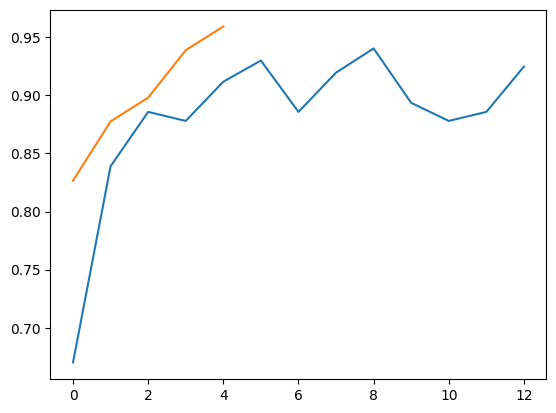

In [ ]:
#코드 5-26. 훈련과 테스트 데이터의 정확도를 그래프로 확인
plt.plot(train_acc_hist)
plt.plot(val_acc_hist)
plt.show()

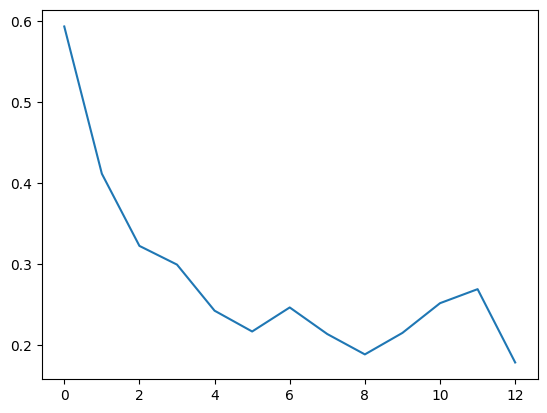

In [ ]:
#코드 5-27. 훈련 데이터의 오차에 대한 그래프 확인
plt.plot(train_loss_hist)
plt.show()

In [ ]:
#코드 5-28. 예측 이미지 출력을 위한 전처리 함수
def im_convert(tensor):
  image = tensor.clone().detach().numpy()
  image = image.transpose(1, 2, 0)
  image = image * (np.array((0.5, 0.5, 0.5)) + np.array((0.5,0.5,0.5)))
  image = image.clip(0,1)
  return image

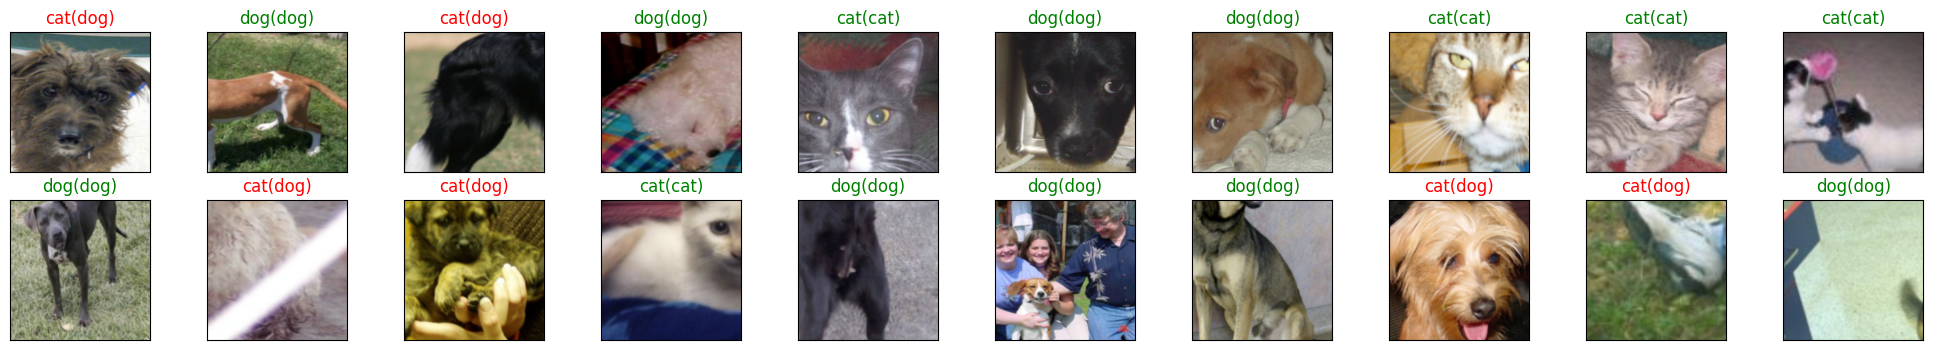

<Figure size 640x480 with 0 Axes>

In [ ]:
#코드 5-29. 개와 고양이 예측 결과 출력
classes = {0: 'cat', 1:'dog'} #개와 고양이 두 개에 대한 레이블

dataiter = iter(test_loader) #테스트 데이터셋을 가져옵니다.
images, labels = next(dataiter) # 테스트 데이터셋에서 이미지와 레이블을 분리하여 가져옵니다
output = model(images)
_, preds = torch.max(output,1)

fig = plt.figure(figsize=(25,4))
for idx in np.arange(20):
  ax = fig.add_subplot(2, 10, idx+1, xticks=[], yticks=[])
  plt.imshow(im_convert(images[idx])) #이미지 출력을 위해 코드5-28에서 정의한 im_convert함수 적용
  ax.set_title(classes[labels[i].item()])
  ax.set_title("{}({})".format(str(classes[preds[idx].item()]),str(classes[labels[idx].
             item()])),color=("green" if preds[idx]==labels[idx] else "red"))
plt.show()
plt.subplots_adjust(bottom=0.2, top=0.6, hspace=0)


```
ax.set_title("{}({})".format(str(classes[preds[idx].item()]),str(classes[labels[idx].
             item()])),color=("green" if preds[idx]==labels[idx] else "red"))
```

-> 이 부분 for루프 안에 들어가야 모든 출력에 컬러 적용돼서 교재와 다르게 수정함(아마 교재 오타로 추정)

- 예측이 정확하지는 않음

  => 훈련 데이터 증가, 에포크 횟수 증가해서 다시 훈련해보기

#5.4 설명 가능한 CNN

##5.4.1 특성 맵 시각화

In [ ]:
!pip install pillow

In [ ]:
#코드 5-30. 필요한 라이브러리 호출
import matplotlib.pyplot as plt
from PIL import Image
import cv2
import torch
import torch.nn.functional as F
import torch.nn as nn
from torchvision.transforms import ToTensor
import torchvision
import torchvision.transforms as transforms
import torchvision.models as models

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [ ]:
#코드 5-31. 설명 가능한 네트워크 생성
class XAI(torch.nn.Module):
  def __init__(self, num_classes=2):
    super(XAI, self).__init__()
    self.features = nn.Sequential( # Changed == to =
        nn.Conv2d(3, 64, kernel_size=3, bias=False),
        nn.BatchNorm2d(64),
        nn.ReLU(inplace=True), #기존의 데이터를 연산의 결괏값으로 대체하는 것을 의미
        nn.Dropout(0.3),
        nn.Conv2d(64, 64, kernel_size=3, padding=1, bias=False),
        nn.BatchNorm2d(64),
        nn.ReLU(inplace=True),
        nn.MaxPool2d(kernel_size=2, stride=2),

        nn.Conv2d(64, 128, kernel_size=3, padding=1, bias=False),
        nn.BatchNorm2d(128),
        nn.ReLU(inplace=True),
        nn.Dropout(0.4),
        nn.Conv2d(128, 128, kernel_size=3, padding=1, bias=False),
        nn.BatchNorm2d(128),
        nn.ReLU(inplace=True),
        nn.MaxPool2d(kernel_size=2, stride=2),

        nn.Conv2d(128, 256, kernel_size=3, padding=1, bias=False),
        nn.BatchNorm2d(256),
        nn.ReLU(inplace=True),
        nn.Dropout(0.4),
        nn.Conv2d(256, 256, kernel_size=3, padding=1, bias=False),
        nn.BatchNorm2d(256),
        nn.ReLU(inplace=True),
        nn.Dropout(0.4),
        nn.Conv2d(256, 256, kernel_size=3, padding=1, bias=False),
        nn.BatchNorm2d(256),
        nn.ReLU(inplace=True),
        nn.MaxPool2d(kernel_size=2, stride=2),

        nn.Conv2d(256, 512, kernel_size=3, padding=1, bias=False),
        nn.BatchNorm2d(512),
        nn.ReLU(inplace=True),
        nn.Dropout(0.4),
        nn.Conv2d(512, 512, kernel_size=3, padding=1, bias=False),
        nn.BatchNorm2d(512),
        nn.ReLU(inplace=True),
        nn.Dropout(0.4),
        nn.Conv2d(512, 512, kernel_size=3, padding=1, bias=False),
        nn.BatchNorm2d(512),
        nn.ReLU(inplace=True),
        nn.MaxPool2d(kernel_size=2, stride=2),

        nn.Conv2d(512, 512, kernel_size=3, padding=1, bias=False),
        nn.BatchNorm2d(512),
        nn.ReLU(inplace=True),
        nn.Dropout(0.4),
        nn.Conv2d(512, 512, kernel_size=3, padding=1, bias=False),
        nn.BatchNorm2d(512),
        nn.ReLU(inplace=True),
        nn.Dropout(0.4),
        nn.Conv2d(512, 512, kernel_size=3, padding=1, bias=False),
        nn.BatchNorm2d(512),
        nn.ReLU(inplace=True),
        nn.MaxPool2d(kernel_size=2, stride=2),
    )
    self.classifier = nn.Sequential(
        nn.Linear(512, 512, bias=False),
        nn.Dropout(0.5),
        nn.BatchNorm1d(512),
        nn.ReLU(inplace=True),
        nn.Dropout(0.5),
        nn.Linear(512, num_classes)
    )
  def forward(self, x):
    x = self.features(x)
    x = x.view(-1,512)
    x = self.classifier(x)
    return F.log_softmax(x)

In [ ]:
#코드 5-32. 모델 객체화
model = XAI() #model이라는 이름의 객체 생성
model.to(device) #model을 장치(CPU 혹은 GPU)에 할당
model.eval() #테스트 데이터에 대한 모델 평가 용도로 사

XAI(
  (features): Sequential(
    (0): Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), bias=False)
    (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU(inplace=True)
    (3): Dropout(p=0.3, inplace=False)
    (4): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
    (5): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (6): ReLU(inplace=True)
    (7): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (8): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
    (9): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (10): ReLU(inplace=True)
    (11): Dropout(p=0.4, inplace=False)
    (12): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
    (13): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (14): ReLU(inplace=True

In [ ]:
#코드 5-33. 특성 맵을 확인하기 위한 클래스 정의
class LayerActivations:
  features = []
  def __init__(self, model, layer_num):
    self.hook = model[layer_num].register_forward_hook(self.hook_fn)

  def hook_fn(self, module, input, output):
    self.features = output.detach().numpy()

  def remove(self): #hook 삭제
    self.hook.remove()

torch.Size([1, 3, 100, 100])


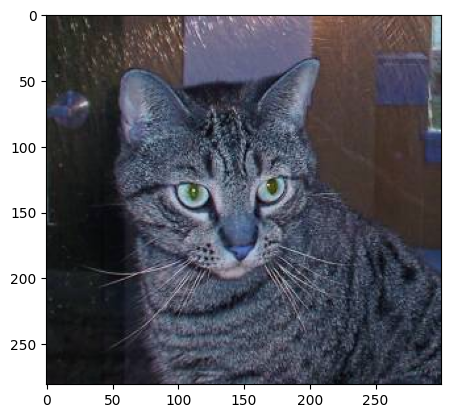

In [ ]:
#코드 5-34. 이미지 호출
img = cv2.imread("/content/drive/MyDrive/Euron9_DL/data/catanddog/train/Cat/1.jpg")
plt.imshow(img)
img = cv2.resize(img, (100,100), interpolation=cv2.INTER_LINEAR)
img = ToTensor()(img).unsqueeze(0)
print(img.shape)

In [ ]:
#코드 5-35. (0): Conv2d 특성 맵 확인
result = LayerActivations(model.features, 0) #0번째 Conv2d 특성 맵 확인

model(img)
activations = result.features

/tmp/ipython-input-1276089081.py:75: UserWarning: Implicit dimension choice for log_softmax has been deprecated. Change the call to include dim=X as an argument.
  return F.log_softmax(x)


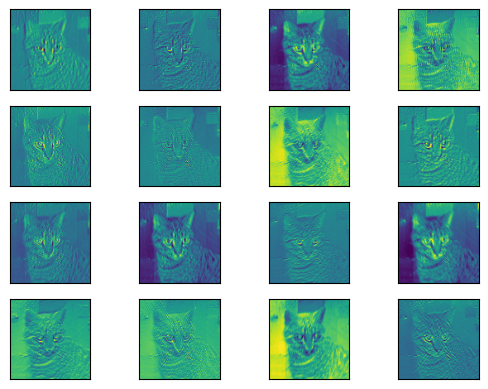

<Figure size 1200x800 with 0 Axes>

In [ ]:
#코드 5-36. 특성 맵 확인
fig, axes = plt.subplots(4,4)
fig = plt.figure(figsize=(12,8))
fig.subplots_adjust(left=0, right=1, bottom=0, top=1, hspace=0.05, wspace=0.05)
for row in range(4):
  for column in range(4):
    axis = axes[row][column]
    axis.get_xaxis().set_ticks([])
    axis.get_yaxis().set_ticks([])
    axis.imshow(activations[0][row*10+column])
plt.show()

In [ ]:
#코드 5-37. 20번째 계층에 대한 특성 맵
result = LayerActivations(model.features, 20) #20번째 Conv2d 특성 맵 확인

model(img)
activations = result.features

/tmp/ipython-input-1276089081.py:75: UserWarning: Implicit dimension choice for log_softmax has been deprecated. Change the call to include dim=X as an argument.
  return F.log_softmax(x)


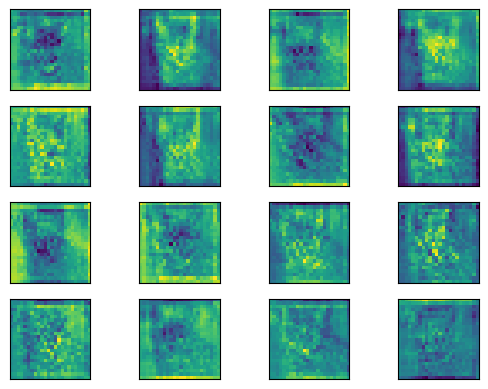

<Figure size 1200x800 with 0 Axes>

In [ ]:
#코드 5-38. 특성 맵 확인
fig, axes = plt.subplots(4,4)
fig = plt.figure(figsize=(12,8))
fig.subplots_adjust(left=0, right=1, bottom=0, top=1, hspace=0.05, wspace=0.05)
for row in range(4):
  for column in range(4):
    axis = axes[row][column]
    axis.get_xaxis().set_ticks([])
    axis.get_yaxis().set_ticks([])
    axis.imshow(activations[0][row*10+column])
plt.show()

In [ ]:
#코드 5-39. 40번째 계층에 대한 특성 맵
result = LayerActivations(model.features, 40) #40번째 Conv2d 특성 맵 확인

model(img)
activations = result.features

/tmp/ipython-input-1276089081.py:75: UserWarning: Implicit dimension choice for log_softmax has been deprecated. Change the call to include dim=X as an argument.
  return F.log_softmax(x)


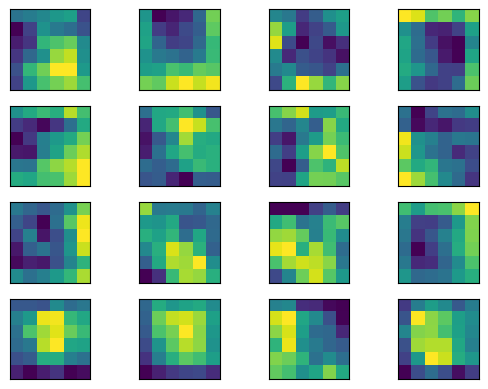

<Figure size 1200x800 with 0 Axes>

In [ ]:
#코드 5-40. 특성 맵 확인
fig, axes = plt.subplots(4,4)
fig = plt.figure(figsize=(12,8))
fig.subplots_adjust(left=0, right=1, bottom=0, top=1, hspace=0.05, wspace=0.05)
for row in range(4):
  for column in range(4):
    axis = axes[row][column]
    axis.get_xaxis().set_ticks([])
    axis.get_yaxis().set_ticks([])
    axis.imshow(activations[0][row*10+column])
plt.show()